In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('IPL Ball-by-Ball 2008-2020.csv')

In [3]:
pd.set_option('display.max_columns',None)
df.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore


In [4]:
df.shape

(193468, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193468 entries, 0 to 193467
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                193468 non-null  int64 
 1   inning            193468 non-null  int64 
 2   over              193468 non-null  int64 
 3   ball              193468 non-null  int64 
 4   batsman           193468 non-null  object
 5   non_striker       193468 non-null  object
 6   bowler            193468 non-null  object
 7   batsman_runs      193468 non-null  int64 
 8   extra_runs        193468 non-null  int64 
 9   total_runs        193468 non-null  int64 
 10  non_boundary      193468 non-null  int64 
 11  is_wicket         193468 non-null  int64 
 12  dismissal_kind    9495 non-null    object
 13  player_dismissed  9495 non-null    object
 14  fielder           6784 non-null    object
 15  extras_type       10233 non-null   object
 16  batting_team      193468 non-null  obj

In [6]:
df.isnull().sum()

id                       0
inning                   0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
batsman_runs             0
extra_runs               0
total_runs               0
non_boundary             0
is_wicket                0
dismissal_kind      183973
player_dismissed    183973
fielder             186684
extras_type         183235
batting_team             0
bowling_team           191
dtype: int64

In [7]:
df.drop(['dismissal_kind','non_boundary','non_striker','batting_team','bowling_team','player_dismissed','fielder','extras_type','bowler'],axis=1,inplace=True)

In [8]:
df.shape

(193468, 9)

In [9]:
for i in df:
    print(i,df[i].unique(),end='\n\n')

id [ 335982  335983  335984  335985  335986  335987  335988  335989  335990
  335991  335992  335993  335994  335995  335996  335997  335998  335999
  336000  336001  336002  336003  336004  336005  336006  336007  336008
  336009  336010  336011  336012  336013  336014  336015  336016  336017
  336018  336019  336020  336021  336022  336023  336024  336025  336026
  336027  336028  336029  336031  336032  336033  336034  336035  336036
  336037  336038  336039  336040  392181  392182  392183  392184  392185
  392186  392188  392189  392190  392191  392192  392194  392195  392196
  392197  392198  392199  392200  392201  392202  392203  392204  392205
  392206  392207  392208  392209  392210  392211  392212  392213  392214
  392215  392216  392217  392218  392219  392220  392221  392222  392223
  392224  392225  392226  392227  392228  392229  392230  392231  392232
  392233  392234  392235  392236  392237  392238  392239  419106  419107
  419108  419109  419110  419111  419112  419113

In [10]:
df.columns

Index(['id', 'inning', 'over', 'ball', 'batsman', 'batsman_runs', 'extra_runs',
       'total_runs', 'is_wicket'],
      dtype='object')

In [11]:
df['Balls_faced']=df.groupby('batsman')['batsman_runs'].transform('count')
#keeping rows where balls faced >100
df=df[df['Balls_faced']>100]
df['total_runs']=df.groupby('batsman')['batsman_runs'].transform('sum')
df['total_outs']=df.groupby('batsman')['is_wicket'].transform('sum')
df['Batting_avg']=df['total_runs']/df['total_outs']
df['Strike_rate']=df['total_runs']*100/df['Balls_faced']

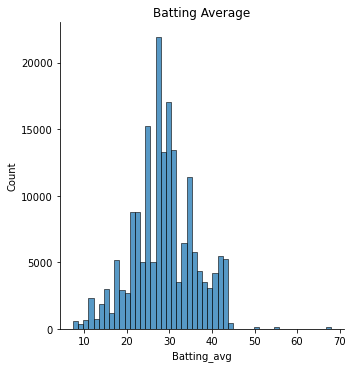

In [12]:
sns.displot(df['Batting_avg'],kde=False,bins=50)
plt.title('Batting Average')
plt.show()

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


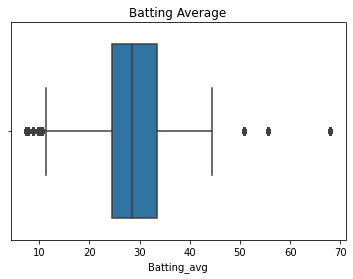

In [13]:
sns.boxplot(df['Batting_avg'],orient='h')
plt.title('Batting Average')
plt.show()

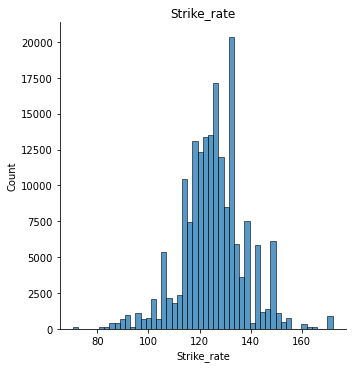

In [14]:
sns.displot(df['Strike_rate'],kde=False,bins=50)
plt.title('Strike_rate')
plt.show()

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


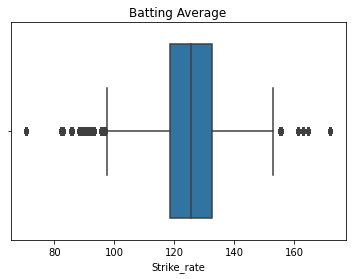

In [15]:
sns.boxplot(df['Strike_rate'],orient='h')
plt.title('Batting Average')
plt.show()

In [16]:
# removing outliers
b_Q1=df['Batting_avg'].quantile(0.25)
b_Q3=df['Batting_avg'].quantile(0.75)

b_IQR=b_Q3-b_Q1
b_lower_limit=b_Q1-(1.5*b_IQR)
b_upper_limit=b_Q3+(1.5*b_IQR)

df=df[(df['Batting_avg']>b_lower_limit)&(df['Batting_avg']<b_upper_limit)]

s_Q1=df['Strike_rate'].quantile(0.25)
s_Q3=df['Strike_rate'].quantile(0.75)

s_IQR=s_Q3-s_Q1
s_lower_limit=s_Q1-(1.5*s_IQR)
s_upper_limit=s_Q3+(1.5*s_IQR)

df=df[(df['Strike_rate']>s_lower_limit)&(df['Strike_rate']<s_upper_limit)]

In [17]:
df

,id,inning,over,ball,batsman,batsman_runs,extra_runs,total_runs,is_wicket,Balls_faced,total_outs,Batting_avg,Strike_rate
1,335982,1,6,6,BB McCullum,1,0,2880,0,2267,106,27.169811,127.040141
2,335982,1,7,1,BB McCullum,0,0,2880,0,2267,106,27.169811,127.040141
3,335982,1,7,2,BB McCullum,1,0,2880,0,2267,106,27.169811,127.040141
5,335982,1,7,4,BB McCullum,1,0,2880,0,2267,106,27.169811,127.040141
7,335982,1,7,6,BB McCullum,1,0,2880,0,2267,106,27.169811,127.040141
...,...,...,...,...,...,...,...,...,...,...,...,...,...
193463,1237181,1,12,5,RR Pant,0,0,2079,0,1416,59,35.237288,146.822034
193464,1237181,1,12,6,RR Pant,1,0,2079,0,1416,59,35.237288,146.822034
193465,1237181,1,13,1,RR Pant,0,1,2079,0,1416,59,35.237288,146.822034
193466,1237181,1,13,2,RR Pant,1,0,2079,0,1416,59,35.237288,146.822034


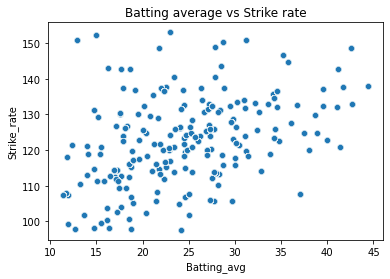

In [18]:
#scatter plot
sns.scatterplot(x=df['Batting_avg'],y=df['Strike_rate'])
plt.title("Batting average vs Strike rate")
plt.show()

In [19]:
from sklearn.cluster import KMeans

In [20]:
wcss=[]

for i in range(1,15):
    kmeans=KMeans(n_init=10,n_clusters=i)
    kmeans.fit(df[['Batting_avg','Strike_rate']])
    wcss.append(kmeans.inertia_)

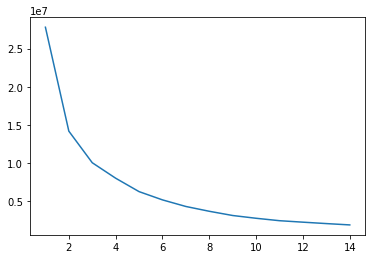

In [21]:
plt.plot(range(1,15),wcss)

In [22]:
kmeans=KMeans(n_init=10, n_clusters=3)

y_kmeans=kmeans.fit_predict(df[['Batting_avg','Strike_rate']])
y_kmeans

array([1, 1, 1, ..., 0, 0, 1])

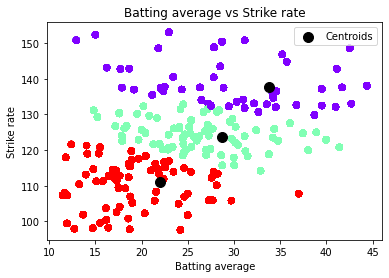

In [23]:
x=kmeans.cluster_centers_[:, 0]
y=kmeans.cluster_centers_[:, 1]
plt.scatter(df['Batting_avg'], df['Strike_rate'], c = y_kmeans, cmap = 'rainbow')
plt.scatter(x, y, s = 100, c = 'black', label = 'Centroids')

plt.title("Batting average vs Strike rate")
plt.xlabel("Batting average")
plt.ylabel("Strike rate")
plt.legend()
plt.show()

In [24]:
# add cluster column to the dataframe
df['cluster'] = y_kmeans

# find the batsmen in each cluster
bat_df = df[['batsman', 'Batting_avg', 'Strike_rate', 'cluster']].drop_duplicates()
bat_df

,batsman,Batting_avg,Strike_rate,cluster
1,BB McCullum,27.169811,127.040141,1
40,DJ Hussey,26.979592,120.072661,1
79,SC Ganguly,24.981481,101.734540,2
121,CL White,27.257143,124.057217,1
123,MV Boucher,26.266667,123.899371,1
...,...,...,...,...
164881,JM Bairstow,39.500000,137.152778,0
167639,SM Curran,23.416667,140.500000,0
170580,R Parag,24.600000,114.953271,2
179486,D Padikkal,33.785714,118.844221,1


In [25]:
# print avg batting average and strike rate for each cluster
bat_df.groupby('cluster')[['Batting_avg','Strike_rate']].mean().sort_values(by = 'Batting_avg')

,Batting_avg,Strike_rate
cluster,,
2,19.511309,110.132240
1,26.341975,124.289534
0,29.482241,138.835554


In [27]:
# giving labels to the cluster
bat_df['cluster']=bat_df['cluster'].replace({1:'aggresive', 0: 'balanced', 2: 'defensive'})

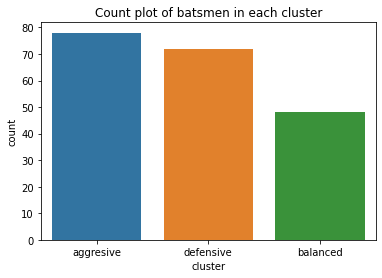

In [28]:
# find the number of batsmen in each cluster
sns.countplot(x = 'cluster', data = bat_df)
plt.title("Count plot of batsmen in each cluster")
plt.show()